<a href="https://colab.research.google.com/github/omarmmowena10/DEPI-Tasks-/blob/main/Copy_of_Regression_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 1 – Simple Linear Regression**
**Goal:** Understand the basics of regression by creating your own dataset.

### Steps:
1. Formulate your own equation in the form:  
   $
   y = m x + c
   $
   
   Example: $y = 2x + 3$
2. Generate X values (at least 100 numbers between your chosen range).
3. Generate Y values using your equation.
4. Add small random noise to Y to make it realistic.
5. Split data into train and test splits
6. Fit a Simple Linear Regression model.
7. Print learned coefficient and intercept.
8. Split the data into train and test sets (80%-20%).
9. Evaluate both train and test using MAE, MSE, R² score.
> Write your notes about model performance and whether the model suffers from overfitting or underfitting.
10. Visualize the points and the fitted line.


Learned Coefficient (m): 2.43
Learned Intercept (c): 11.92
------------------------------
Metrics for Train Split:
  MAE: 3.75
  MSE: 21.87
  R² Score: 0.98

Metrics for Test Split:
  MAE: 2.90
  MSE: 18.10
  R² Score: 0.99



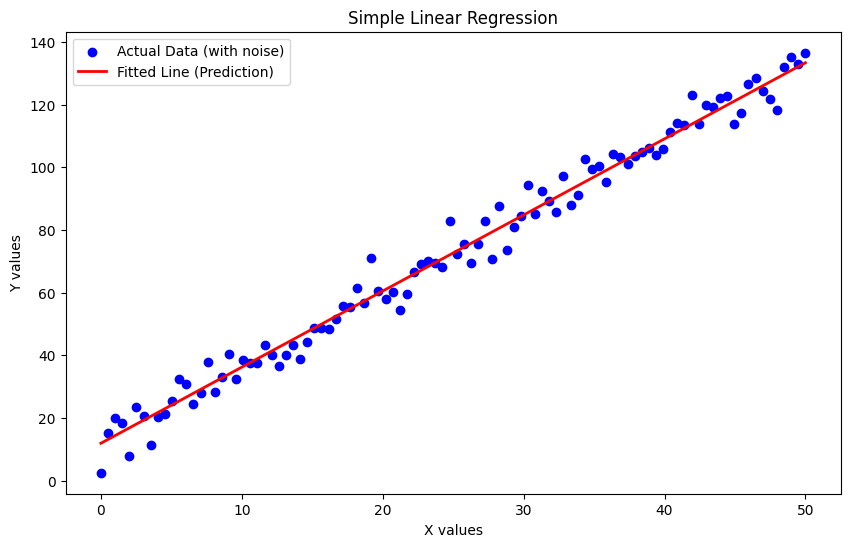

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


m_true = 2.5
c_true = 10


X = np.linspace(0, 50, 100).reshape(-1, 1)


y = m_true * X + c_true


noise = np.random.normal(0, 5, size=X.shape)
y_with_noise = y + noise

X_train, X_test, y_train, y_test = train_test_split(X, y_with_noise, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)


print(f"Learned Coefficient (m): {model.coef_[0][0]:.2f}")
print(f"Learned Intercept (c): {model.intercept_[0]:.2f}")
print("-" * 30)


def evaluate(X_data, y_data, label):
    predictions = model.predict(X_data)
    mae = mean_absolute_error(y_data, predictions)
    mse = mean_squared_error(y_data, predictions)
    r2 = r2_score(y_data, predictions)
    print(f"Metrics for {label}:")
    print(f"  MAE: {mae:.2f}")
    print(f"  MSE: {mse:.2f}")
    print(f"  R² Score: {r2:.2f}\n")

evaluate(X_train, y_train, "Train Split")
evaluate(X_test, y_test, "Test Split")


plt.figure(figsize=(10, 6))
plt.scatter(X, y_with_noise, color='blue', label='Actual Data (with noise)')
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Fitted Line (Prediction)')
plt.title('Simple Linear Regression')
plt.xlabel('X values')
plt.ylabel('Y values')
plt.legend()
plt.show()

# **Assignment 2 – Multiple Linear Regression**
**Goal:** See how multiple features affect predictions.

### Steps:
1. Formulate your own equation:
   $
   y = a_1 x_1 + a_2 x_2 + c
   $
2. Generate `x1` and `x2` values (at least 100 numbers each).
3. Generate Y values with noise.
4. Split data into train and test splits
5. Fit a Multiple Linear Regression model.
6. Compare coefficients and intercept to your original equation.
7. Evaluate both train and test using MAE, MSE, R² score.
> Write your notes about model performance and whether the model suffers from overfitting or underfitting.



In [2]:


a1_true = 3.0
a2_true = 1.5
c_true = 5.0


np.random.seed(42)
x1 = np.random.rand(100, 1) * 100
x2 = np.random.rand(100, 1) * 50


X = np.hstack((x1, x2))


y = (a1_true * x1) + (a2_true * x2) + c_true
noise = np.random.normal(0, 10, size=y.shape)
y_with_noise = y + noise


X_train, X_test, y_train, y_test = train_test_split(X, y_with_noise, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)

print("--- Comparison of Coefficients ---")
print(f"Original Equation: y = {a1_true}*x1 + {a2_true}*x2 + {c_true}")
print(f"Learned Model:    y = {model.coef_[0][0]:.2f}*x1 + {model.coef_[0][1]:.2f}*x2 + {model.intercept_[0]:.2f}")
print("-" * 40)


def evaluate_model(X_data, y_data, label):
    predictions = model.predict(X_data)
    mae = mean_absolute_error(y_data, predictions)
    mse = mean_squared_error(y_data, predictions)
    r2 = r2_score(y_data, predictions)
    print(f"Results for {label}:")
    print(f"  MAE: {mae:.2f}")
    print(f"  MSE: {mse:.2f}")
    print(f"  R² Score: {r2:.2f}")

evaluate_model(X_train, y_train, "Train Set")
evaluate_model(X_test, y_test, "Test Set")

--- Comparison of Coefficients ---
Original Equation: y = 3.0*x1 + 1.5*x2 + 5.0
Learned Model:    y = 2.98*x1 + 1.66*x2 + 2.93
----------------------------------------
Results for Train Set:
  MAE: 7.86
  MSE: 101.89
  R² Score: 0.99
Results for Test Set:
  MAE: 7.33
  MSE: 66.64
  R² Score: 0.99


# **Assignment 3 – Polynomial Regression**
**Goal:** Model non-linear relationships.

### Steps:
1. Formulate your own equation:
   $
   y = ax^2 + bx + c
   $
2. Generate X values and Y values with noise.
3. Use `PolynomialFeatures` to transform X.
4. Split the data into train and test sets (80%-20%).
5. Fit a Linear Regression model on transformed features.
6. Evaluate both train and test using MAE, MSE, R² score.
> Write your notes about model performance and whether the model suffers from overfitting or underfitting.



[Train Set] -> MAE: 11.07, MSE: 192.11, R²: 0.96
[Test Set] -> MAE: 9.48, MSE: 156.02, R²: 0.97


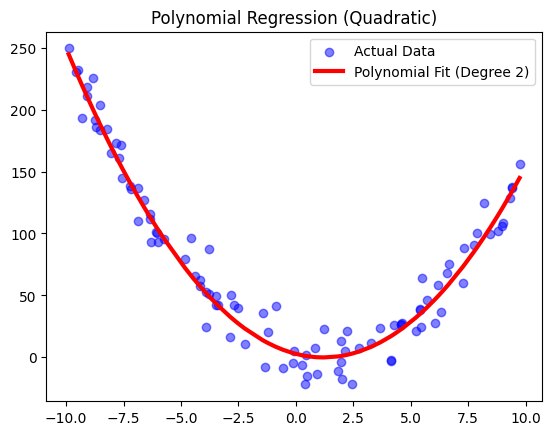

In [3]:

from sklearn.preprocessing import PolynomialFeatures



a, b, c = 2, -5, 3


np.random.seed(42)
X = np.sort(np.random.uniform(-10, 10, 100)).reshape(-1, 1)
y = a * X**2 + b * X + c
noise = np.random.normal(0, 15, size=X.shape)
y_with_noise = y + noise


poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_poly, y_with_noise, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)


def evaluate(X_data, y_data, label):
    preds = model.predict(X_data)
    mae = mean_absolute_error(y_data, preds)
    mse = mean_squared_error(y_data, preds)
    r2 = r2_score(y_data, preds)
    print(f"[{label}] -> MAE: {mae:.2f}, MSE: {mse:.2f}, R²: {r2:.2f}")

evaluate(X_train, y_train, "Train Set")
evaluate(X_test, y_test, "Test Set")


plt.scatter(X, y_with_noise, color='blue', alpha=0.5, label='Actual Data')
plt.plot(X, model.predict(X_poly), color='red', linewidth=3, label='Polynomial Fit (Degree 2)')
plt.title('Polynomial Regression (Quadratic)')
plt.legend()
plt.show()

## Machine Learning Project Pipeline

### 1. **Exploratory Data Analysis (EDA)**
- Inspect dataset structure (`.info()`, `.describe()`)
- Check for missing values and duplicates
- Understand feature types (numeric, categorical, datetime, etc.)
- Visualize data distributions (histograms, boxplots, bar charts)
- Identify correlations between features and target
- Detect outliers and anomalies

---

### 2. **Data Cleaning**
- Handle missing values (drop, fill with mean/median/mode, or use predictive imputation)
- Remove duplicates
- Fix inconsistent data formats (e.g., date parsing, string trimming)
- Correct data entry errors or outliers (if verified)

---

### 3. **Data Pre-processing**
- Convert data types if necessary (e.g., `object` to `datetime` or numeric)
- Handle categorical variables:
  - **Encoding**:
    - One-Hot Encoding (for nominal categories)
    - Ordinal Encoding (for ordered categories)
- Verify numeric features:
  - Check for incorrect values (e.g., negative ages)
  - Apply transformations if needed (e.g., log transform for skewed data)

---

### 4. **Scaling Numeric Features**
- Standardization (`StandardScaler`) — mean = 0, std = 1
- Normalization (`MinMaxScaler`) — values between 0 and 1
- Robust Scaling (less sensitive to outliers)

---

### 5. **Splitting Data**
- **Train-Test Split**
  - Typically 70–80% for training, 20–30% for testing
  - Use `train_test_split` from `sklearn`
  - Set `random_state` for reproducibility
- Optional: create a **validation set** for model tuning

---

### 6. **Modeling**
- Choose model type based on task:
  - **Regression:** Linear Regression
- Train the model on training data (Your target is `price`)

---

### 7. **Evaluating the Model**
- **On Training Data**:
  - Evaluate for underfitting (low train performance)
- **On Testing Data**:
  - Evaluate for overfitting (high train, low test performance)
- Metrics:
  - **Regression:** MAE, MSE, RMSE, R²

---

### 8. **Final Steps**
- Save the model (`joblib` or `pickle`)



In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("rohitgrewal/airlines-flights-data")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/airlines-flights-data


In [ ]:
os.listdir(path)

['airlines_flights_data.csv']

In [ ]:
full_path = os.path.join(path,os.listdir(path)[0])

In [ ]:
import pandas as pd
df = pd.read_csv(full_path)

In [ ]:
df

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


## OPTIONAL SUGGESTIONS for Visualizations for Flight Price Dataset
> **YOU MUST MAKE VISUALIZATIONS. THESE ARE ONLY SUGGESTIONS**
### 1. **Numeric Data Visualizations**
(Columns: `duration`, `days_left`, `price`)

**a. Distribution of Numeric Features**
- **Histograms / KDE plots**  
  - Price distribution — check for skewness.  
  - Duration distribution — detect common flight lengths.  
  - Days left — reveal booking patterns.

**b. Boxplots for Outlier Detection**
- Boxplot of `price` — spot extreme values.
- Boxplot of `duration` grouped by `class` or `airline`.

**c. Price vs Numeric Feature Relationships**
- Scatter plot: `price` vs `duration` (color by `class` or `airline`).
- Scatter plot: `price` vs `days_left` (color by `class` or `stops`).

---

### 2. **Categorical Data Visualizations**
(Columns: `airline`, `flight`, `source_city`, `departure_time`, `stops`, `arrival_time`, `destination_city`, `class`)

**a. Price Trends by Category**
- **Boxplots**
  - `price` by `airline` — compare average fares.
  - `price` by `source_city` or `destination_city`.
  - `price` by `stops` — direct vs connecting flights.

**b. Frequency Counts**
- Bar plots of `airline` frequency — market share.
- Bar plots of `source_city` and `destination_city` — most common routes.
- Bar plots of `departure_time` (morning, afternoon, evening, night) — popular times.

**c. Grouped Statistics**
- Mean `price` by `airline` and `class` — grouped bar plots.
- Mean `price` by `(source_city, destination_city)` pairs.

---

### 3. **Mixed Insights**

**a. Heatmaps / Pivot Tables**
- Pivot table: average `price` for each `(source_city, destination_city)` pair — show as heatmap.
- Pivot table: average `price` for each `(airline, class)` — reveal premium vs economy gap.

**b. Correlation Heatmap (Numeric Only)**
- Show correlation between `duration`, `days_left`, and `price`.

---
*These visualizations can reveal pricing patterns, airline competitiveness, route popularity, and booking behavior trends.*
